Load the dataset

In [1]:
import pandas as pd
import numpy as np
import numpy.random as r
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score, confusion_matrix
)

np.random.seed(42)

Load the dataset

In [2]:
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Check missing values

In [3]:
df.isnull().sum().sort_values(ascending=False)

artists             1
album_name          1
track_name          1
Unnamed: 0          0
mode                0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
speechiness         0
key                 0
loudness            0
track_id            0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64

Check target distribution

In [4]:
df["track_genre"].value_counts().head(20)

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000
new-age              1000
mpb                  1000
minimal-techno       1000
metalcore            1000
metal                1000
mandopop             1000
malay                1000
latino               1000
latin                1000
kids                 1000
Name: count, dtype: int64

Find the 10 most common genres, then make a new dataset that only includes songs from those genres.

In [5]:
top_10 = df["track_genre"].value_counts().head(10).index.tolist()

df_filtered = df[df["track_genre"].isin(top_10)].copy()

df_small = (
    df_filtered.groupby("track_genre", group_keys=False)
    .sample(n=200, random_state=42)
    .reset_index(drop=True)
)

print(df_small.shape)
print(df_small["track_genre"].value_counts())

(2000, 21)
track_genre
acoustic             200
opera                200
pagode               200
party                200
piano                200
pop                  200
pop-film             200
power-pop            200
progressive-house    200
punk-rock            200
Name: count, dtype: int64


Select numeric audio features

In [42]:
features = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

target = "track_genre"

X = df_small[features].copy()
y = df_small[target].copy()

print(X.shape)
print(y.shape)

(2000, 14)
(2000,)


Encode genre labels

In [43]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Genres:", list(label_encoder.classes_))

Genres: ['acoustic', 'opera', 'pagode', 'party', 'piano', 'pop', 'pop-film', 'power-pop', 'progressive-house', 'punk-rock']


Train/validation/test split. 700 training songs, 150 validation songs, 150 test songs.

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1400, 14)
Validation shape: (300, 14)
Test shape: (300, 14)


Scale the features

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# -------------- Neural Network

In [25]:
# One-hot encode targets
def to_onehot(y, n_classes=10):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

y_v_train = to_onehot(y_train)
y_v_val   = to_onehot(y_val)
y_v_test  = to_onehot(y_test)

print("y_v_train shape:", y_v_train.shape)
print("Example one-hot:", y_v_train[0])

y_v_train shape: (1400, 10)
Example one-hot: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


# Activation functions

In [26]:
def relu(z):
    """ReLU activation: max(0, z)"""
    return np.maximum(0, z)

def relu_deriv(z):
    """Derivative of ReLU"""
    return (z > 0).astype(float)

def softmax(z):
    """Numerically stable softmax"""
    e = np.exp(z - np.max(z))
    return e / e.sum()

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(z):
    return sigmoid(z) * (1 - sigmoid(z))

In [27]:
#Xavier weight initialization ----------

def init_weights(nn_structure, seed=42):
    """
    Xavier initialization: W ~ N(0, 1/fan_in)
    Much better than uniform [0,1) for sigmoid/ReLU networks.
    """
    np.random.seed(seed)
    W, b = {}, {}
    for l in range(1, len(nn_structure)):
        fan_in = nn_structure[l - 1]
        W[l] = np.random.randn(nn_structure[l], fan_in) * np.sqrt(1.0 / fan_in)
        b[l] = np.zeros(nn_structure[l])
    return W, b

def init_grads(nn_structure):
    tri_W, tri_b = {}, {}
    for l in range(1, len(nn_structure)):
        tri_W[l] = np.zeros((nn_structure[l], nn_structure[l-1]))
        tri_b[l] = np.zeros(nn_structure[l])
    return tri_W, tri_b

In [28]:
def feed_forward(x, W, b):
    """
    Hidden layers: ReLU
    Output layer:  Softmax
    Returns a (activations) and z (pre-activations) dicts.
    """
    n_layers = len(W)
    a = {1: x}
    z = {}
    for l in range(1, n_layers + 1):
        z[l+1] = W[l].dot(a[l]) + b[l]
        if l < n_layers:          # hidden layer → ReLU
            a[l+1] = relu(z[l+1])
        else:                     # output layer → Softmax
            a[l+1] = softmax(z[l+1])
    return a, z

In [29]:
#Loss: cross-entropy ----------
def cross_entropy(y_true, y_pred):
    """Cross-entropy for a single sample."""
    eps = 1e-12
    return -np.sum(y_true * np.log(y_pred + eps))

def compute_cost_batch(Y_true, X, W, b, lambda_reg):
    """
    Compute average cross-entropy loss + L2 regularization over a dataset.
    Y_true: (N, n_classes) one-hot matrix
    """
    N = X.shape[0]
    total = 0.0
    for i in range(N):
        a, _ = feed_forward(X[i], W, b)
        total += cross_entropy(Y_true[i], a[len(W)+1])
    total /= N
    # L2 penalty
    l2 = (lambda_reg / 2) * sum(np.sum(W[l]**2) for l in W)
    return total + l2

In [30]:
# Backpropagation & training ----------

def train_nn(nn_structure, X_train, y_v_train, X_val, y_v_val,
             n_iter=2000, alpha=0.05, lambda_reg=0.01, seed=42, verbose=True):
    """
    Train neural network with:
      - ReLU hidden activations
      - Softmax output
      - Cross-entropy loss
      - L2 regularization
      - Xavier weight init

    Returns: W, b, train_costs, val_costs
    """
    W, b = init_weights(nn_structure, seed=seed)
    n_layers = len(W)
    N = X_train.shape[0]
    train_costs, val_costs = [], []

    if verbose:
        print(f'  Training {nn_structure}, λ={lambda_reg}, α={alpha}')

    for cnt in range(n_iter):
        tri_W, tri_b = init_grads(nn_structure)

        for i in range(N):
            a, z = feed_forward(X_train[i], W, b)
            delta = {}

            # Output layer delta (softmax + cross-entropy simplifies to a - y)
            delta[n_layers + 1] = a[n_layers + 1] - y_v_train[i]

            # Hidden layer deltas (ReLU)
            for l in range(n_layers, 1, -1):
                delta[l] = W[l].T.dot(delta[l+1]) * relu_deriv(z[l])

            # Accumulate gradients
            for l in range(1, n_layers + 1):
                tri_W[l] += np.outer(delta[l+1], a[l])
                tri_b[l] += delta[l+1]

        #Gradient descent step with L2 regularization
        for l in range(1, n_layers + 1):
            W[l] -= alpha * (tri_W[l] / N + lambda_reg * W[l])
            b[l] -= alpha * (tri_b[l] / N)

        #Record costs every 100 iterations (saves time)
        if cnt % 100 == 0:
            tc = compute_cost_batch(y_v_train, X_train, W, b, lambda_reg)
            vc = compute_cost_batch(y_v_val,   X_val,   W, b, lambda_reg)
            train_costs.append(tc)
            val_costs.append(vc)

    return W, b, train_costs, val_costs


def predict(W, b, X):
    """Predict class labels for dataset X."""
    n_layers = len(W) + 1
    preds = []
    for i in range(X.shape[0]):
        a, _ = feed_forward(X[i], W, b)
        preds.append(np.argmax(a[n_layers]))
    return np.array(preds)

In [31]:
ARCHITECTURES = {
    "T0_Linear":      [14, 10],
    "T1_Shallow":     [14, 30, 10],
    "T2_DeeperNarrow":[14, 20, 20, 10],
    "T3_Wider":       [14, 64, 10],
    "T4_DeepWide":    [14, 64, 32, 10],
}

LAMBDA_VALUES = [0, 0.0001, 0.001, 0.01, 0.1, 1.0]

# Training hyperparameters (same for all to ensure fair comparison)
N_ITER  = 2000
ALPHA   = 0.05

#Total experiments: 5 architectures × 6 λ values = 30 models

In [33]:
#ALL EXPERIMENTS: Train each architecture with each λ, record results and curves

results = []      # list of result dicts → becomes the results table
curves  = {}      # {(arch_name, lambda): (train_costs, val_costs)}
models  = {}      # {(arch_name, lambda): (W, b)} — keep best for final eval

for arch_name, nn_structure in ARCHITECTURES.items():
    print(f"\n{'='*55}")
    print(f"Architecture: {arch_name}  {nn_structure}")
    print(f"{'='*55}")

    for lam in LAMBDA_VALUES:
        W, b, train_costs, val_costs = train_nn(
            nn_structure,
            X_train_scaled, y_v_train,
            X_val_scaled,   y_v_val,
            n_iter=N_ITER, alpha=ALPHA, lambda_reg=lam,
            verbose=True
        )

        # Evaluate on train and validation
        y_pred_train = predict(W, b, X_train_scaled)
        y_pred_val   = predict(W, b, X_val_scaled)

        train_acc = accuracy_score(y_train, y_pred_train)
        val_acc   = accuracy_score(y_val,   y_pred_val)
        val_prec  = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
        val_rec   = recall_score(y_val, y_pred_val, average='macro', zero_division=0)
        val_f1    = f1_score(y_val, y_pred_val, average='macro', zero_division=0)

        results.append({
            'Architecture':  arch_name,
            'Structure':     str(nn_structure),
            'Lambda':        lam,
            'Train Acc':     round(train_acc, 4),
            'Val Acc':       round(val_acc,   4),
            'Val Precision': round(val_prec,  4),
            'Val Recall':    round(val_rec,   4),
            'Val F1':        round(val_f1,    4),
            'Final Train Loss': round(train_costs[-1], 4),
            'Final Val Loss':   round(val_costs[-1],   4),
        })

        curves[(arch_name, lam)]  = (train_costs, val_costs)
        models[(arch_name, lam)]  = (W, b)

        print(f"    λ={lam:<8} | Train: {train_acc:.3f} | Val: {val_acc:.3f} | F1: {val_f1:.3f}")

print("\nAll experiments complete.")


Architecture: T0_Linear  [14, 10]
  Training [14, 10], λ=0, α=0.05


KeyboardInterrupt: 

# Results

In [ ]:
results_df = pd.DataFrame(results)

# Highlight the row with best validation accuracy per architecture
best_per_arch = results_df.loc[results_df.groupby('Architecture')['Val Acc'].idxmax()]

print("\nBest model per architecture (by Val Acc):")
print(best_per_arch[['Architecture','Lambda','Train Acc','Val Acc','Val F1']].to_string(index=False))

# Overall best
best_row = results_df.loc[results_df['Val Acc'].idxmax()]
print(f"\nOverall best: {best_row['Architecture']}  λ={best_row['Lambda']}  Val Acc={best_row['Val Acc']:.4f}")

In [ ]:
# --- Plot 1: Validation Accuracy vs Lambda, per architecture ---

fig, ax = plt.subplots(figsize=(10, 6))
lambda_labels = [str(l) for l in LAMBDA_VALUES]
x = np.arange(len(LAMBDA_VALUES))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, arch_name in enumerate(ARCHITECTURES):
    arch_results = results_df[results_df['Architecture'] == arch_name].sort_values('Lambda')
    ax.plot(x, arch_results['Val Acc'].values, marker='o', linewidth=2,
            color=colors[i], label=arch_name)

ax.set_xticks(x)
ax.set_xticklabels(lambda_labels)
ax.set_xlabel('Regularization (λ)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Validation Accuracy vs. Regularization Strength\nby Architecture', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Plot 2: Learning curves for each architecture at λ=0.001 ---

PLOT_LAMBDA = 0.001  # change this to inspect other lambda values
iters = np.arange(0, N_ITER, 100)

fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(18, 4), sharey=False)

for i, arch_name in enumerate(ARCHITECTURES):
    tc, vc = curves[(arch_name, PLOT_LAMBDA)]
    axes[i].plot(iters, tc, label='Train', color='steelblue')
    axes[i].plot(iters, vc, label='Val',   color='tomato')
    axes[i].set_title(arch_name.replace('_', '\n'), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Iteration', fontsize=9)
    if i == 0:
        axes[i].set_ylabel('Cross-Entropy Loss', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f'Learning Curves (λ = {PLOT_LAMBDA})', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# --- Plot 3: Train vs Val accuracy (bias-variance view) ---

fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(18, 5), sharey=True)

for i, arch_name in enumerate(ARCHITECTURES):
    arch_results = results_df[results_df['Architecture'] == arch_name].sort_values('Lambda')
    x = np.arange(len(LAMBDA_VALUES))
    axes[i].plot(x, arch_results['Train Acc'].values, 'o--', color='steelblue', label='Train')
    axes[i].plot(x, arch_results['Val Acc'].values,   's-',  color='tomato',    label='Val')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([str(l) for l in LAMBDA_VALUES], rotation=45, ha='right', fontsize=8)
    axes[i].set_title(arch_name.replace('_', '\n'), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('λ', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_ylabel('Accuracy', fontsize=11)
    axes[i].legend(fontsize=8)

fig.suptitle('Train vs. Validation Accuracy by Architecture (Bias-Variance Tradeoff)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# --- Plot 4: Precision, Recall, F1 for best model per architecture ---

metrics = ['Val Precision', 'Val Recall', 'Val F1']
x = np.arange(len(ARCHITECTURES))
width = 0.25
arch_names = list(ARCHITECTURES.keys())

fig, ax = plt.subplots(figsize=(12, 6))
for j, metric in enumerate(metrics):
    vals = [best_per_arch[best_per_arch['Architecture'] == a][metric].values[0]
            for a in arch_names]
    ax.bar(x + j*width, vals, width, label=metric)

ax.set_xticks(x + width)
ax.set_xticklabels([a.replace('_', '\n') for a in arch_names], fontsize=9)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision / Recall / F1 — Best Model per Architecture', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Plot 5: Learning curves for best architecture across all lambda values ---

BEST_ARCH = best_row['Architecture']
iters = np.arange(0, N_ITER, 100)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, lam in enumerate(LAMBDA_VALUES):
    tc, vc = curves[(BEST_ARCH, lam)]
    axes[i].plot(iters, tc, label='Train', color='steelblue')
    axes[i].plot(iters, vc, label='Val',   color='tomato')
    axes[i].set_title(f'λ = {lam}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('Loss')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f'Learning Curves — {BEST_ARCH} — All λ values',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Final Eval on test

In [ ]:
# Identify best model from validation results
best_arch = best_row['Architecture']
best_lam  = best_row['Lambda']

print(f"Best model selected: {best_arch}  λ={best_lam}")
print(f"Validation accuracy: {best_row['Val Acc']:.4f}")
print("-" * 50)

W_best, b_best = models[(best_arch, best_lam)]

# Evaluate on test set
y_pred_test = predict(W_best, b_best, X_test_s)

test_acc  = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
test_rec  = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
test_f1   = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

print(f"TEST Accuracy:  {test_acc:.4f}")
print(f"TEST Precision: {test_prec:.4f}")
print(f"TEST Recall:    {test_rec:.4f}")
print(f"TEST F1:        {test_f1:.4f}")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_test,
                             target_names=label_encoder.classes_))

# SVM

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Log-tranformed features

In [14]:
X_train_log = X_train.copy()
X_val_log = X_val.copy()
X_test_log = X_test.copy()

for col in ["duration_ms", "tempo", "popularity"]:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_val_log[col] = np.log1p(X_val_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])

scaler_log = StandardScaler()

X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_val_log_scaled = scaler_log.transform(X_val_log)
X_test_log_scaled = scaler_log.transform(X_test_log)

PCA features

In [17]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train_scaled.shape)
print("PCA shape:", X_train_pca.shape)

Original shape: (1400, 14)
PCA shape: (1400, 12)


/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/jeremytob/Desktop/Intro_to_ML_final_

Polynomial features

In [18]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Polynomial shape:", X_train_poly.shape)

Polynomial shape: (1400, 119)


Store the 4 feature sets

In [19]:
svm_feature_sets = {
    "original": (X_train_scaled, X_val_scaled, X_test_scaled),
    "pca": (X_train_pca, X_val_pca, X_test_pca),
    "polynomial": (X_train_poly, X_val_poly, X_test_poly),
    "log": (X_train_log_scaled, X_val_log_scaled, X_test_log_scaled)
}

In [44]:
svm_results = []
C_values = [0.01, 0.1, 1, 10, 50, 100]

for feature_name, (Xtr, Xv, Xt) in svm_feature_sets.items():
    for c in C_values:
        model = SVC(kernel="rbf", C=c, gamma="scale")
        model.fit(Xtr, y_train)

        y_train_pred = model.predict(Xtr)
        y_val_pred = model.predict(Xv)

        svm_results.append({
            "model": "SVM",
            "feature_set": feature_name,
            "C": c,
            "train_accuracy": accuracy_score(y_train, y_train_pred),
            "val_accuracy": accuracy_score(y_val, y_val_pred),
            "val_precision": precision_score(y_val, y_val_pred, average="macro", zero_division=0),
            "val_recall": recall_score(y_val, y_val_pred, average="macro", zero_division=0),
            "val_f1": f1_score(y_val, y_val_pred, average="macro", zero_division=0)
        })

The results table

In [45]:
svm_results_df = pd.DataFrame(svm_results)
print("Number of SVM models trained:", len(svm_results_df))
svm_results_df.sort_values(by="val_accuracy", ascending=False).head(24)

Number of SVM models trained: 24


,model,feature_set,C,train_accuracy,val_accuracy,val_precision,val_recall,val_f1
2,SVM,original,1.00,0.745000,0.686667,0.698647,0.686667,0.688275
3,SVM,original,10.00,0.903571,0.680000,0.685024,0.680000,0.679765
8,SVM,pca,1.00,0.737857,0.680000,0.690072,0.680000,0.679209
9,SVM,pca,10.00,0.890714,0.676667,0.685235,0.676667,0.676629
14,SVM,polynomial,1.00,0.755000,0.676667,0.686242,0.676667,0.677067
10,SVM,pca,50.00,0.972857,0.660000,0.665181,0.660000,0.660461
21,SVM,log,10.00,0.880714,0.656667,0.663689,0.656667,0.655864
11,SVM,pca,100.00,0.990000,0.656667,0.665221,0.656667,0.658153
20,SVM,log,1.00,0.717857,0.653333,0.666536,0.653333,0.653554
15,SVM,polynomial,10.00,0.908571,0.646667,0.648382,0.646667,0.646578


Validation accuracy vs C for each feature set

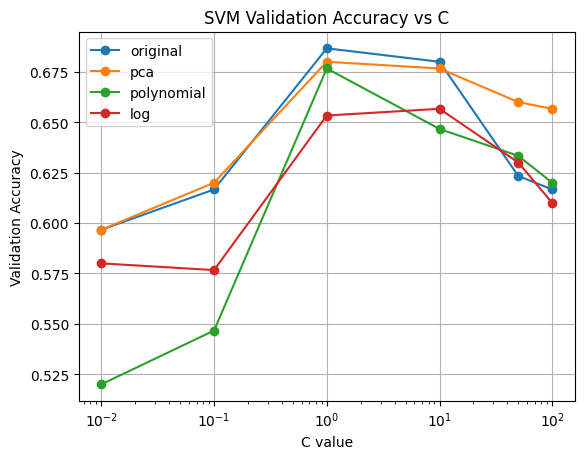

In [46]:
for feature_name in svm_results_df["feature_set"].unique():
    subset = svm_results_df[svm_results_df["feature_set"] == feature_name]
    plt.plot(subset["C"], subset["val_accuracy"], marker="o", label=feature_name)

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Validation Accuracy")
plt.title("SVM Validation Accuracy vs C")
plt.legend()
plt.grid(True)
plt.show()

Bar chart of best validation accuracy by feature set

In [ ]:
best_by_feature = svm_results_df.groupby("feature_set")["val_accuracy"].max()

best_by_feature.plot(kind="bar")
plt.xlabel("Feature Set")
plt.ylabel("Best Validation Accuracy")
plt.title("Best SVM Validation Accuracy by Feature Set")
plt.xticks(rotation=0)
plt.show()

# Logistic Regression

We will be using softmax for multi class logistic regression.

In [57]:
# reuse the same feature sets already built for SVM
lr_feature_sets = {
    "original":   (X_train_scaled,     X_val_scaled,     X_test_scaled),
    "log":        (X_train_log_scaled,  X_val_log_scaled,  X_test_log_scaled),
    "pca":        (X_train_pca,         X_val_pca,         X_test_pca),
    "polynomial": (X_train_poly,        X_val_poly,        X_test_poly),
}

C_values = [0.01, 0.1, 1, 10, 50, 100]
lr_results = []

print(lr_feature_sets["original"][0].shape)


(1400, 14)


In [58]:
for feature_name, (Xtr, Xv, Xt) in lr_feature_sets.items():
    print(f"\n{'='*55}")
    print(f"Feature set: {feature_name}")
    print(f"{'='*55}")

    for c in C_values:
        model = LogisticRegression(
            C=c, solver='lbfgs', max_iter=2000, random_state=42
        )
        model.fit(Xtr, y_train)

        y_train_pred = model.predict(Xtr)
        y_val_pred   = model.predict(Xv)

        lr_results.append({
            "feature_set":    feature_name,
            "C":              c,
            "train_accuracy": accuracy_score(y_train, y_train_pred),
            "val_accuracy":   accuracy_score(y_val,   y_val_pred),
            "val_precision":  precision_score(y_val, y_val_pred, average="macro", zero_division=0),
            "val_recall":     recall_score(y_val,   y_val_pred, average="macro", zero_division=0),
            "val_f1":         f1_score(y_val,       y_val_pred, average="macro", zero_division=0),
        })

        print(f"    C={c:<6} | Train: {lr_results[-1]['train_accuracy']:.3f} | Val: {lr_results[-1]['val_accuracy']:.3f} | F1: {lr_results[-1]['val_f1']:.3f}")

print("\nAll LR experiments complete. Models trained:", len(lr_results))
print("number of models trained:", len(lr_results))



Feature set: original
    C=0.01   | Train: 0.565 | Val: 0.597 | F1: 0.581
    C=0.1    | Train: 0.589 | Val: 0.627 | F1: 0.610
    C=1      | Train: 0.595 | Val: 0.627 | F1: 0.615
    C=10     | Train: 0.597 | Val: 0.623 | F1: 0.611
    C=50     | Train: 0.597 | Val: 0.623 | F1: 0.611
    C=100    | Train: 0.597 | Val: 0.623 | F1: 0.611

Feature set: log
    C=0.01   | Train: 0.552 | Val: 0.573 | F1: 0.557
    C=0.1    | Train: 0.576 | Val: 0.590 | F1: 0.580
    C=1      | Train: 0.581 | Val: 0.597 | F1: 0.588
    C=10     | Train: 0.586 | Val: 0.597 | F1: 0.589
    C=50     | Train: 0.586 | Val: 0.590 | F1: 0.583
    C=100    | Train: 0.586 | Val: 0.590 | F1: 0.583

Feature set: pca
    C=0.01   | Train: 0.557 | Val: 0.587 | F1: 0.570
    C=0.1    | Train: 0.574 | Val: 0.600 | F1: 0.585
    C=1      | Train: 0.572 | Val: 0.600 | F1: 0.586
    C=10     | Train: 0.571 | Val: 0.597 | F1: 0.584
    C=50     | Train: 0.570 | Val: 0.597 | F1: 0.584
    C=100    | Train: 0.570 | Val: 0.597

/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: Runti

    C=10     | Train: 0.866 | Val: 0.600 | F1: 0.600
    C=50     | Train: 0.888 | Val: 0.580 | F1: 0.581
    C=100    | Train: 0.889 | Val: 0.563 | F1: 0.567

All LR experiments complete. Models trained: 24
number of models trained: 24


/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encounter

The results table

In [59]:
lr_results_df = pd.DataFrame(lr_results)

#Export results to Excel for easier analysis
lr_results_df.to_excel("lr_results.xlsx", index=False)

best_lr_per_feat = lr_results_df.loc[lr_results_df.groupby('feature_set')['val_accuracy'].idxmax()]

print("Full results table:")
print(lr_results_df.sort_values(['feature_set', 'C']).to_string(index=False))


Full results table:
feature_set      C  train_accuracy  val_accuracy  val_precision  val_recall   val_f1
        log   0.01        0.552143      0.573333       0.559900    0.573333 0.556715
        log   0.10        0.575714      0.590000       0.582160    0.590000 0.580372
        log   1.00        0.581429      0.596667       0.589821    0.596667 0.588119
        log  10.00        0.586429      0.596667       0.591227    0.596667 0.588526
        log  50.00        0.586429      0.590000       0.586122    0.590000 0.582515
        log 100.00        0.585714      0.590000       0.586122    0.590000 0.582515
   original   0.01        0.565000      0.596667       0.597857    0.596667 0.580510
   original   0.10        0.588571      0.626667       0.616359    0.626667 0.610021
   original   1.00        0.595000      0.626667       0.618742    0.626667 0.615066
   original  10.00        0.597143      0.623333       0.614956    0.623333 0.611303
   original  50.00        0.597143      0.623

In [75]:
print("\nBest model per feature set (by Val Acc):")
print(best_lr_per_feat[['feature_set','C','train_accuracy','val_accuracy','val_f1']].to_string(index=False))

best_lr_row = lr_results_df.loc[lr_results_df['val_accuracy'].idxmax()]
best_lr_per_feat.to_excel("lr_results1.xlsx", index=False)

print("\nBest model per feature set (by Val Acc):")
print(best_lr_per_feat['feature_set'].to_string(index=False))

print(f"\nOverall best: {best_lr_row['feature_set']}  C={best_lr_row['C']}  Val Acc={best_lr_row['val_accuracy']:.4f}")



Best model per feature set (by Val Acc):
feature_set    C  train_accuracy  val_accuracy   val_f1
        log 1.00        0.581429      0.596667 0.588119
   original 0.10        0.588571      0.626667 0.610021
        pca 0.10        0.573571      0.600000 0.584974
 polynomial 0.01        0.700714      0.666667 0.667824

Best model per feature set (by Val Acc):
       log
  original
       pca
polynomial

Overall best: polynomial  C=0.01  Val Acc=0.6667


Line plot of Val Accuracy vs C value

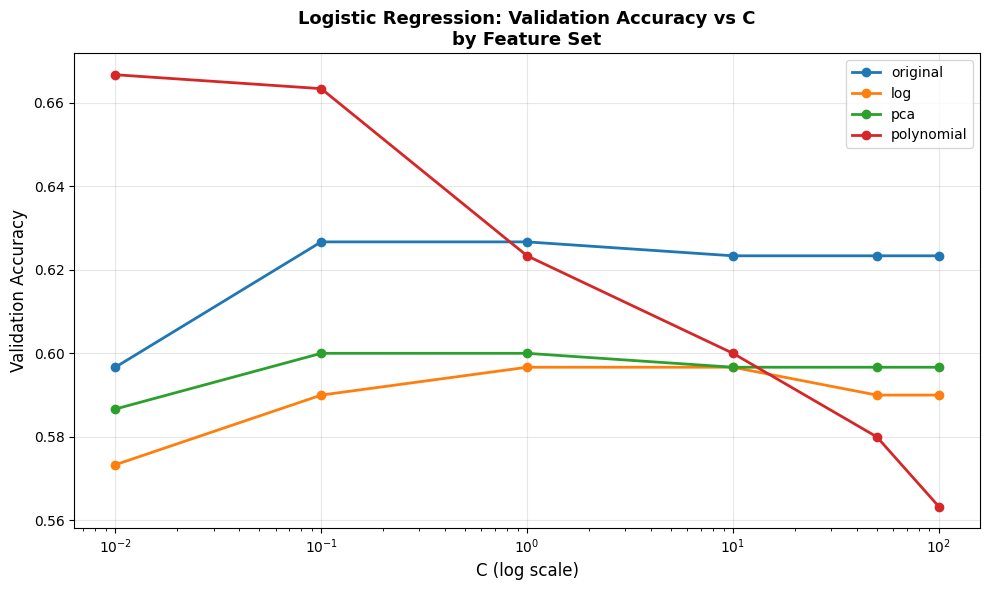

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, feature_name in enumerate(lr_feature_sets):
    subset = lr_results_df[lr_results_df['feature_set'] == feature_name].sort_values('C')
    ax.plot(subset['C'], subset['val_accuracy'], marker='o', linewidth=2,
            color=colors[i], label=feature_name)

ax.set_xscale('log')
ax.set_xlabel('C (log scale)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Logistic Regression: Validation Accuracy vs C\nby Feature Set', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Train vs validation accuracy — bias/variance view

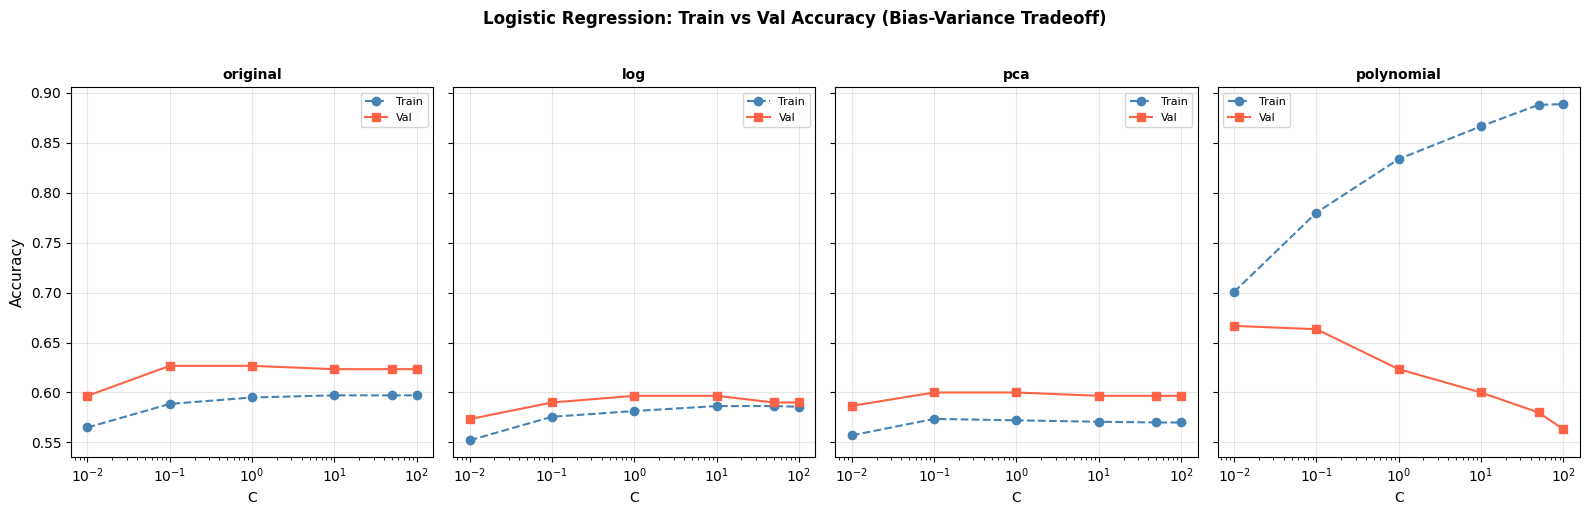

In [62]:
fig, axes = plt.subplots(1, len(lr_feature_sets), figsize=(16, 5), sharey=True)

for i, feature_name in enumerate(lr_feature_sets):
    subset = lr_results_df[lr_results_df['feature_set'] == feature_name].sort_values('C')
    axes[i].plot(subset['C'], subset['train_accuracy'], 'o--', color='steelblue', label='Train')
    axes[i].plot(subset['C'], subset['val_accuracy'],   's-',  color='tomato',    label='Val')
    axes[i].set_xscale('log')
    axes[i].set_title(feature_name, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('C', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)
    if i == 0:
        axes[i].set_ylabel('Accuracy', fontsize=11)

fig.suptitle('Logistic Regression: Train vs Val Accuracy (Bias-Variance Tradeoff)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Precision / Recall / F1 — best model per feature set

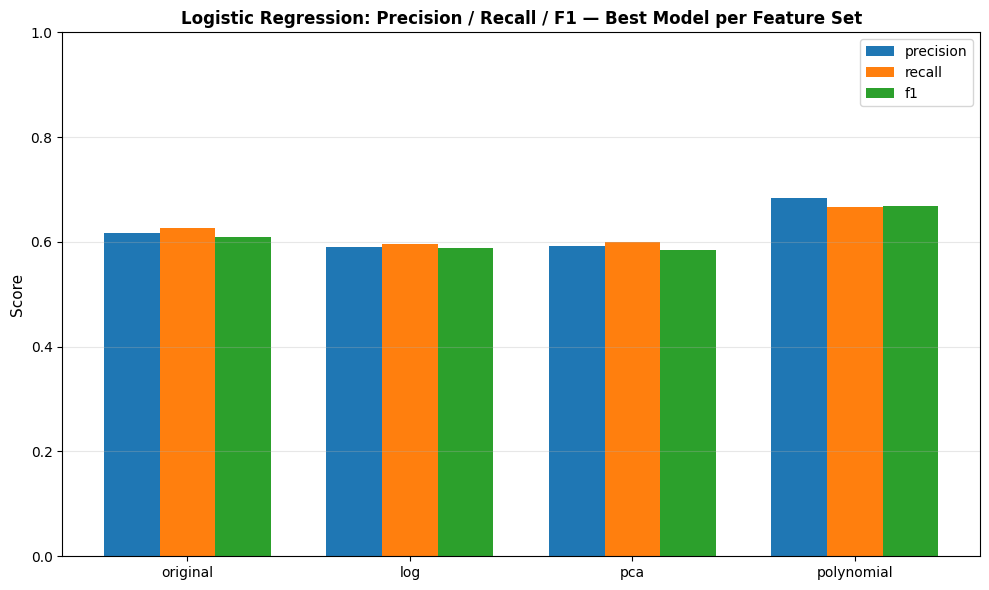

In [63]:
metrics = ['val_precision', 'val_recall', 'val_f1']
feat_names = list(lr_feature_sets.keys())
x = np.arange(len(feat_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for j, metric in enumerate(metrics):
    vals = [best_lr_per_feat[best_lr_per_feat['feature_set'] == f][metric].values[0] for f in feat_names]
    ax.bar(x + j*width, vals, width, label=metric.replace('val_', ''))

ax.set_xticks(x + width)
ax.set_xticklabels(feat_names, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Logistic Regression: Precision / Recall / F1 — Best Model per Feature Set',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print("=" * 60)
print("FINAL TEST SET EVALUATION — Best Model per Feature Set")
print("=" * 60)

test_rows = []

for feat in lr_feature_sets:
    #Grab best C for this feature set from validation results
    best_c = lr_results_df[lr_results_df["feature_set"] == feat].sort_values("val_accuracy", ascending=False).iloc[0]["C"]
    
    Xtr, Xv, Xt = lr_feature_sets[feat]
    
    model = LogisticRegression(C=best_c, solver="lbfgs", max_iter=1000, random_state=42)
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xt)
    
    test_acc  = accuracy_score(y_test, y_pred)
    test_prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    test_rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    test_f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)
    
    test_rows.append({
        "feature_set": feat,
        "best_C":      best_c,
        "test_acc":    round(test_acc,  4),
        "test_prec":   round(test_prec, 4),
        "test_rec":    round(test_rec,  4),
        "test_f1":     round(test_f1,   4),
    })
    
    print(f"\n  Feature set : {feat}")
    print(f"  Best C      : {best_c}")
    print(f"  Test Acc    : {test_acc:.4f}")
    print(f"  Test Prec   : {test_prec:.4f}")
    print(f"  Test Recall : {test_rec:.4f}")
    print(f"  Test F1     : {test_f1:.4f}")

print("\n" + "=" * 60)
test_df = pd.DataFrame(test_rows)
print(test_df.to_string(index=False))

best_test = test_df.loc[test_df["test_acc"].idxmax()]
print(f"\nOverall best on test: {best_test['feature_set']}  C={best_test['best_C']}  Test Acc={best_test['test_acc']:.4f}")

FINAL TEST SET EVALUATION — Best Model per Feature Set

  Feature set : original
  Best C      : 0.1
  Test Acc    : 0.5967
  Test Prec   : 0.5938
  Test Recall : 0.5967
  Test F1     : 0.5904

  Feature set : log
  Best C      : 1.0
  Test Acc    : 0.5967
  Test Prec   : 0.5980
  Test Recall : 0.5967
  Test F1     : 0.5917

  Feature set : pca
  Best C      : 0.1
  Test Acc    : 0.6000
  Test Prec   : 0.6071
  Test Recall : 0.6000
  Test F1     : 0.5973

  Feature set : polynomial
  Best C      : 0.01
  Test Acc    : 0.6300
  Test Prec   : 0.6437
  Test Recall : 0.6300
  Test F1     : 0.6310

feature_set  best_C  test_acc  test_prec  test_rec  test_f1
   original    0.10    0.5967     0.5938    0.5967   0.5904
        log    1.00    0.5967     0.5980    0.5967   0.5917
        pca    0.10    0.6000     0.6071    0.6000   0.5973
 polynomial    0.01    0.6300     0.6437    0.6300   0.6310

Overall best on test: polynomial  C=0.01  Test Acc=0.6300


/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/jeremytob/Desktop/Intro_to_ML_final_project/Intro_to_ML_final_project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: Runti